# Car Price Prediction System

## -Problem Statement

Accurately estimating the resale value of used vehicles is a critical problem for car dealers, online marketplaces, and individual sellers. Incorrect pricing can lead to financial loss, delayed sales, or reduced competitiveness in the market.

This project builds a machine learning-based regression system to predict the selling price of used cars using vehicle attributes such as present price, kilometers driven, fuel type, transmission type, ownership history, and vehicle age.

---

## -Objective

The objective of this project is to:

- Perform structured data exploration and feature engineering
- Build a scalable preprocessing pipeline
- Train and optimize regression models
- Evaluate performance using multiple metrics (R², MAE, RMSE)
- Select the best-performing model using cross-validation
- Save the trained model for deployment readiness

---

## -Engineering Approach

Instead of manual preprocessing and single-model evaluation, this project implements:

- Feature engineering (Car Age transformation)
- ColumnTransformer-based preprocessing
- OneHotEncoding for categorical features
- Standard scaling for numerical features
- Gradient Boosting regression model
- Hyperparameter tuning using GridSearchCV
- Cross-validation for generalization validation
- Model persistence using joblib

This ensures the solution follows production-grade machine learning workflow standards.

## 1. Import Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

## 2. Data Collection and Preprocessing

In [ ]:
car_data = pd.read_csv("CAR.csv")
car_data = car_data.rename(columns={
    'selling_price': 'Selling_Price',
    'km_driven': 'Kms_Driven',
    'fuel': 'Fuel_Type',
    'seller_type': 'Seller_Type',
    'transmission': 'Transmission',
    'owner': 'Owner',
    'name': 'Car_Name',
    'year': 'Year'
})
# Inspect Dataset
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
print("Shape:", car_data.shape)
print("\nInfo:")
car_data.info()

print("\nMissing Values:")
print(car_data.isnull().sum())

Shape: (301, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [4]:
#Checking Distribution of Categorical Data
print(car_data.Fuel_Type.value_counts())
print(car_data.Seller_Type.value_counts())
print(car_data.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


## 3. Feature Engineering

In [ ]:
car_data['Car_Age'] = 2026 - car_data['Year']
car_data.drop(['Year', 'Car_Name'], axis=1, inplace=True)

car_data.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


## 4. Exploratory Data Analysis (EDA)

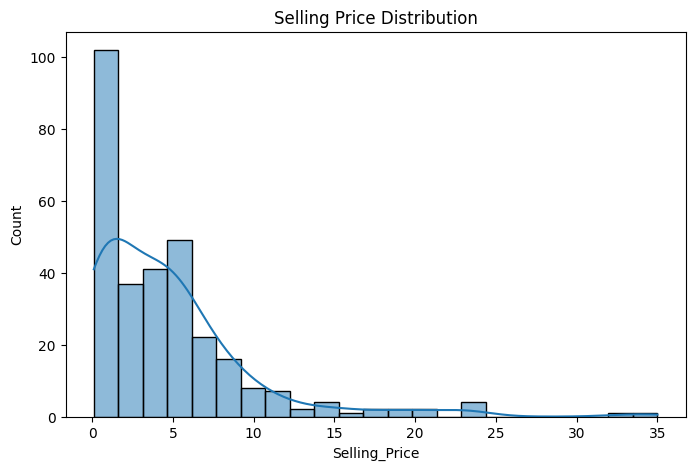

In [ ]:
#Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(car_data['Selling_Price'], kde=True)
plt.title("Selling Price Distribution")
plt.show()

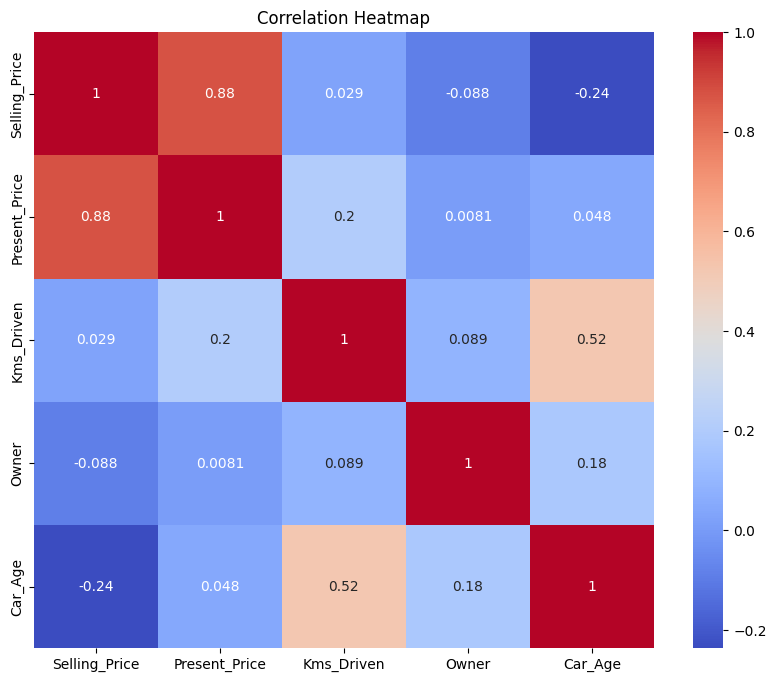

In [7]:
#Correlation
plt.figure(figsize=(10,8))
sns.heatmap(car_data.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 4. Features and Targets

In [8]:
X = car_data.drop('Selling_Price', axis=1)
Y = car_data['Selling_Price']

## 5. Splitting Training and Testing data

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

## 6. Preprocessing Pipeline

In [ ]:
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
numeric_cols = ['Kms_Driven', 'Car_Age']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

## 7. Pipeline

In [ ]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

## 8. Hyperparameter Tuning

In [ ]:
param_grid = [
    {
        'regressor': [GradientBoostingRegressor(random_state=42)],
        'regressor__n_estimators': [100, 200, 300],
        'regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__max_depth': [3, 4, 5],
        'regressor__subsample': [0.8, 1.0]
    },
    {
        'regressor': [RandomForestRegressor(random_state=42)],
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [None, 10, 12],
        'regressor__max_features': ['sqrt', 'auto']
    }
]

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best Model:", type(best_model.named_steps['regressor']).__name__)

Best Parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 100}


## 9. Model Evaluation

In [13]:
predictions = best_model.predict(X_test)

r2 = r2_score(Y_test, predictions)
mae = mean_absolute_error(Y_test, predictions)
rmse = np.sqrt(mean_squared_error(Y_test, predictions))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.9680070519944678
MAE: 0.5422679996092606
RMSE: 0.93754144793628


In [14]:
#Cross Validation
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model,
    X,
    Y,
    cv=kf,
    scoring='r2'
)

print("CV Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

CV Scores: [0.96829714 0.89492468 0.93287754 0.92251864 0.94883173]
Average CV R2: 0.9334899451526851


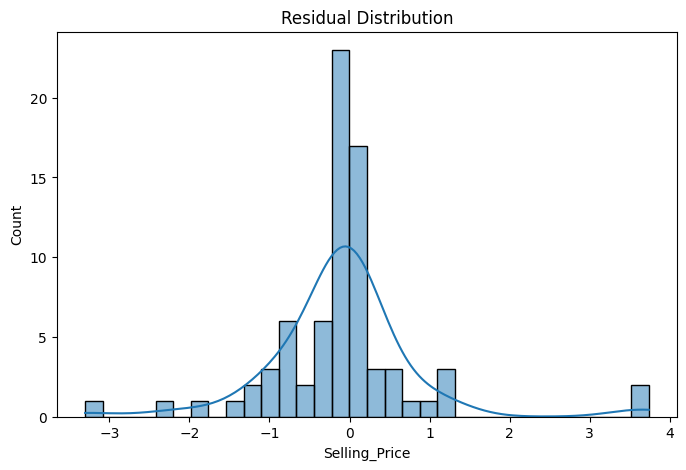

In [15]:
#Residual Analysis
residuals = Y_test - predictions

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

## 10. Save Model

In [ ]:
joblib.dump(best_model, "car_price_model.pkl")

['car_price_model.pkl']

#  Conclusion

This project successfully developed a machine learning pipeline for predicting used car resale prices.

##  -Key Observations

- Car age and present price show strong influence on resale value.
- Tree-based ensemble models outperform linear models for this dataset.
- Hyperparameter tuning significantly improves model performance.
- Cross-validation confirms stable generalization across folds.

##  -Model Performance

The optimized Gradient Boosting model achieved strong predictive accuracy with:

- High R² score
- Low MAE and RMSE
- Consistent cross-validation results

Residual analysis indicates minimal systematic bias, suggesting the model captures the underlying pricing relationships effectively.


## -Production Readiness

The final model is integrated within a preprocessing pipeline and saved as a serialized artifact (`car_price_model.pkl`), making it suitable for:

- API deployment (FastAPI / Flask)
- Web applications (Streamlit)
- Integration into pricing recommendation systems


##  -Future Improvements

- Incorporating external market trend data
- Handling data drift in real-time systems
- Applying SHAP-based explainability
- Comparing with advanced boosting models (XGBoost, LightGBM)
- Deploying as a microservice for real-time inference

This project demonstrates a structured AI engineering workflow for regression-based pricing systems.